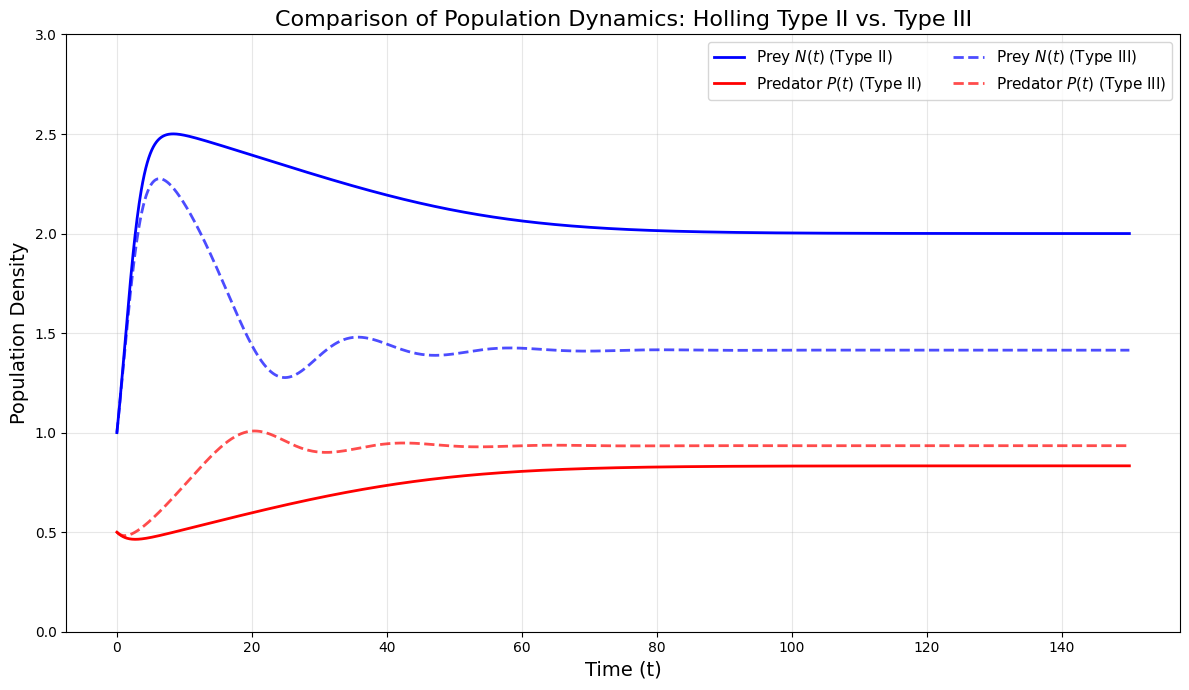

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def type2_system(y, t, r, K, alpha, h, e, gamma):
    N, P = y
    dNdt = r * N * (1 - N / K) - (alpha * N * P) / (1 + alpha * h * N)
    dPdt = (e * alpha * N * P) / (1 + alpha * h * N) - gamma * P
    return [dNdt, dPdt]

def type3_system(y, t, r, K, alpha, h, e, gamma):
    N, P = y
    dNdt = r * N * (1 - N / K) - (alpha * N**2 * P) / (1 + alpha * h * N**2)
    dPdt = (e * alpha * N**2 * P) / (1 + alpha * h * N**2) - gamma * P
    return [dNdt, dPdt]

r = 1.0
K = 3.0 
alpha = 2.0 
h = 1.0 
e = 0.5 
gamma = 0.4
t = np.linspace(0, 150, 2000)
y0 = [1.0, 0.5]

sol_ii = odeint(type2_system, y0, t, args=(r, K, alpha, h, e, gamma))
sol_iii = odeint(type3_system, y0, t, args=(r, K, alpha, h, e, gamma))

plt.figure(figsize=(12, 7))
plt.plot(t, sol_ii[:, 0], 'b-', linewidth=2, label='Prey $N(t)$ (Type II)')
plt.plot(t, sol_ii[:, 1], 'r-', linewidth=2, label='Predator $P(t)$ (Type II)')
plt.plot(t, sol_iii[:, 0], 'b--', linewidth=2, alpha=0.7, label='Prey $N(t)$ (Type III)')
plt.plot(t, sol_iii[:, 1], 'r--', linewidth=2, alpha=0.7, label='Predator $P(t)$ (Type III)')
plt.title('Comparison of Population Dynamics: Holling Type II vs. Type III', fontsize=16)
plt.xlabel('Time (t)', fontsize=14)
plt.ylabel('Population Density', fontsize=14)
plt.legend(loc='upper right', ncol=2, fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, max(np.max(sol_ii), np.max(sol_iii)) * 1.2)
plt.tight_layout()
plt.savefig('type2_vs_type3_comparison.png', dpi=300)
plt.show()